# Les données SIG (Systeme d'Information Géographique)

Données SIG au format GDP (Geodatabase) issus de la base de donné HydroSHEDS d'Europe et Moyen-Orient, mis sur pied par la World Wildlife Fund US.

https://www.hydrosheds.org/products/hydrorivers

In [1]:
folder_name = "./HydroRIVERS_v10_eu.gdb/"

### Affichage des bruts avec Geopandas

HydroRIVERS ne contient pas des "rivières" au sens géographique (Rhône, Durance, Seine, etc.).

Il contient des tronçons élémentaires.

Ainsi les données prennent la forme d'un graphe orienté où :

- un noeud = un tronçon de rivière
- une arête = connexion hydrologique
- `NEXT_DOWN` indique l'aval.

In [2]:
import geopandas as gpd

gdf = gpd.read_file(folder_name, layer="HydroRIVERS_v10_eu")

# ça n'affiche que les 5 premières lignes du GeoDataFrame
gdf.head()

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,Shape_Length,geometry
0,20000001,0,20000001,0.69,0.0,5.6,13.230000,13.200000,0,0.175,1,1,7,2.120062e+09,0.043750,"MULTILINESTRING ((59.2625 81.78958, 59.30625 8..."
1,20000002,0,20000002,4.09,0.0,7.7,30.580000,30.600000,0,0.401,1,1,7,2.120062e+09,0.186428,"MULTILINESTRING ((58.24167 81.77708, 58.13542 ..."
2,20000003,0,20000003,5.09,0.0,9.2,20.299999,20.299999,0,0.262,1,1,7,2.120062e+09,0.151665,"MULTILINESTRING ((57.50833 81.51042, 57.44375 ..."
3,20000004,0,20000004,3.95,0.0,9.8,8.420000,8.400000,0,0.107,1,1,7,2.120062e+09,0.039731,"MULTILINESTRING ((57.07917 81.50417, 57.06875 ..."
4,20000005,0,20000005,1.77,0.0,12.0,6.010000,33.700001,0,0.420,2,1,7,2.120062e+09,0.061785,"MULTILINESTRING ((56.55208 81.33125, 56.54792 ..."


Chaque tronçon possède des propriétés :
- `HYRIV_ID` : ID unique du tronçon hydrographique.

- `NEXT_DOWN` : identifiant du tronçon situé immédiatement à l'aval. Une valeur de 0 indique généralement que le tronçon se jette dans la mer, un lac terminal ou sort du domaine étudié.

- `MAIN_RIV` : identifiant du cours d'eau principal auquel appartient le tronçon. Tous les tronçons d'un même fleuve principal partagent la même valeur.

- `LENGTH_KM` : longueur du tronçon ($\text{km}$).

- `DIST_DN_KM` : distance séparant l'extrémité aval du tronçon de l'exutoire du bassin ou de l'océan ($\text{km}$).

- `DIST_UP_KM` : distance séparant l'extrémité amont du tronçon de l'exutoire ($\text{km}$). Sonc on a approximativement : `LENGTH_KM` = `DIST_UP_KM` - `DIST_DN_KM`

- `CATCH_SKM` : superficie du bassin versant local drainé directement par ce tronçon ($\text{km}^2$), sans compter les contributions des tronçons amont.

- `UPLAND_SKM` : superficie totale drainée en amont de l'extrémité aval du tronçon ($\text{km}^2$), incluant tous les affluents amont.

- `ENDORHEIC` : indicateur de bassin endoréique.
  - 0 : bassin exoréique (écoulement vers l'océan).
  - 1 : bassin endoréique (écoulement vers les terres, sans débouché vers l'océan).

- `DIS_AV_CMS` : débit moyen annuel estimé à l'extrémité aval du tronçon ($\text{m}^3/\text{s}$).

- `ORD_STRA` : ordre de Strahler du tronçon.
  - deux cours d'eau d'ordre n donnent un cours d'eau d'ordre n+1 ;
  - la confluence d'ordres différents conserve l'ordre le plus élevé.

- `ORD_CLAS` : classe d'ordre de cours d'eau utilisée par HydroRIVERS pour regrouper plusieurs ordres de Strahler en grandes catégories hiérarchiques.

- `ORD_FLOW` : classement des tronçons selon leur importance hydrologique (basé sur le débit et la structure du réseau) utilisé pour identifier les axes principaux du réseau.

- `HYBAS_L12` : identifiant du sous-bassin HydroBASINS de niveau 12 contenant le tronçon.

- `Shape_Length` : longueur géométrique du tronçon dans le système de coordonnées du fichier. Cette valeur est principalement technique et peut différer légèrement de `LENGTH_KM`.

- `geometry` : géométrie du tronçon. Une rivière est représentée par une succession de coordonnées géographiques stockées sous forme de LineString ou MultiLineString.

In [ ]:
# Nombre de lignes du GeoDataFrame, donc le nombre de tronçons de rivières dans le fichier SIG
len(gdf)

938544

In [13]:
# Nombre de réseaux principaux
list_ID_main = gdf["MAIN_RIV"].unique()

len(list_ID_main)

24185

In [ ]:
# Affichage des 10 tronçons de rivières principaux avec les plus grands débits moyens (DIS_AV_CMS) 
# mais réseaux principaux différents (MAIN_RIV)

list_ID_biggest = []
list_main = []
for i in range(10):
    # Dabord on recupère l'ID du tornçon avec le plus grand débit moyen
    # Mais il ne faut pas que ce tronçon appartienne à un réseau principal déjà sélectionné
    ID_biggest = gdf[gdf["MAIN_RIV"].isin(list_main) == False]["DIS_AV_CMS"].idxmax()
    # Puis on ajoute l'ID du tronçon dans la liste de ceux ayant le plus gros debit moyen
    list_ID_biggest.append(int(ID_biggest))
    # Ensuite on ajoute l'ID du réseau principal de ce tronçon dans la liste des réseaux principaux déjà sélectionnés
    list_main.append(gdf.loc[ID_biggest, "MAIN_RIV"])

print("Liste des 10 tronçons de rivières principaux avec les plus grands débits moyens (DIS_AV_CMS) mais réseaux principaux différents (MAIN_RIV) :")
print(list_ID_biggest)

gdf_biggest = gdf.loc[list_ID_biggest]
gdf_biggest

Liste des 10 tronçons de rivières principaux avec les plus grands débits moyens (DIS_AV_CMS) mais réseaux principaux différents (MAIN_RIV) :
[398409, 493763, 24095, 81952, 790834, 161111, 323927, 504797, 414170, 533314]


,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,Shape_Length,geometry
398409,20398410,20399624,20490321,0.550000,657.400024,3173.600098,0.140000,1.358642e+06,0,8241.002930,9,1,3,2.120457e+09,0.005893,"MULTILINESTRING ((44.83125 49.00625, 44.82708 ..."
493763,20493764,20493959,20498112,5.430000,175.399994,2776.000000,13.250000,7.758331e+05,0,6763.633789,8,1,3,2.120542e+09,0.062796,"MULTILINESTRING ((28.22292 45.46458, 28.23542 ..."
24095,20024096,0,20024096,4.210000,0.000000,1622.300049,20.610001,3.126760e+05,0,4837.946777,8,1,3,2.120044e+09,0.071129,"MULTILINESTRING ((53.89375 67.96875, 53.93542 ..."
81952,20081953,0,20081953,3.900000,0.000000,1588.300049,24.100000,3.466658e+05,0,3261.727051,8,1,3,2.120042e+09,0.067678,"MULTILINESTRING ((40.59792 64.51458, 40.58125 ..."
790834,20790835,20791150,20791150,2.780000,2.900000,3046.600098,7.620000,8.295907e+05,0,2959.695068,8,1,3,2.120074e+09,0.025000,"MULTILINESTRING ((48.44792 30.03958, 48.44792 ..."
161111,20161112,20161180,20165518,12.150000,110.000000,950.400024,37.820000,2.761007e+05,0,2729.733887,8,1,3,2.120231e+09,0.111785,"MULTILINESTRING ((31.22292 60.29792, 31.22292 ..."
323927,20323928,0,20323928,1.660000,0.000000,1270.000000,3.840000,1.630079e+05,0,2451.121094,7,1,3,2.120023e+09,0.020118,"MULTILINESTRING ((4.16875 51.95208, 4.16458 51..."
504797,20504798,0,20504798,27.889999,0.000000,696.299988,117.860001,7.328900e+04,0,1840.625000,6,1,3,2.120013e+09,0.325173,"MULTILINESTRING ((12.23542 45.00625, 12.23958 ..."
414170,20414171,20414886,20467169,1.850000,407.700012,1626.199951,4.130000,4.643175e+05,0,1796.090942,8,1,3,2.120473e+09,0.016667,"MULTILINESTRING ((35.09792 48.42708, 35.09792 ..."
533314,20533315,20533725,20537764,4.120000,26.799999,892.200012,19.440001,9.574540e+04,0,1726.885986,7,1,3,2.120017e+09,0.041963,"MULTILINESTRING ((4.66042 43.60208, 4.66042 43..."


# Affichage de l'ensemble des cours d'eau d'Europe et Moyen-Orient

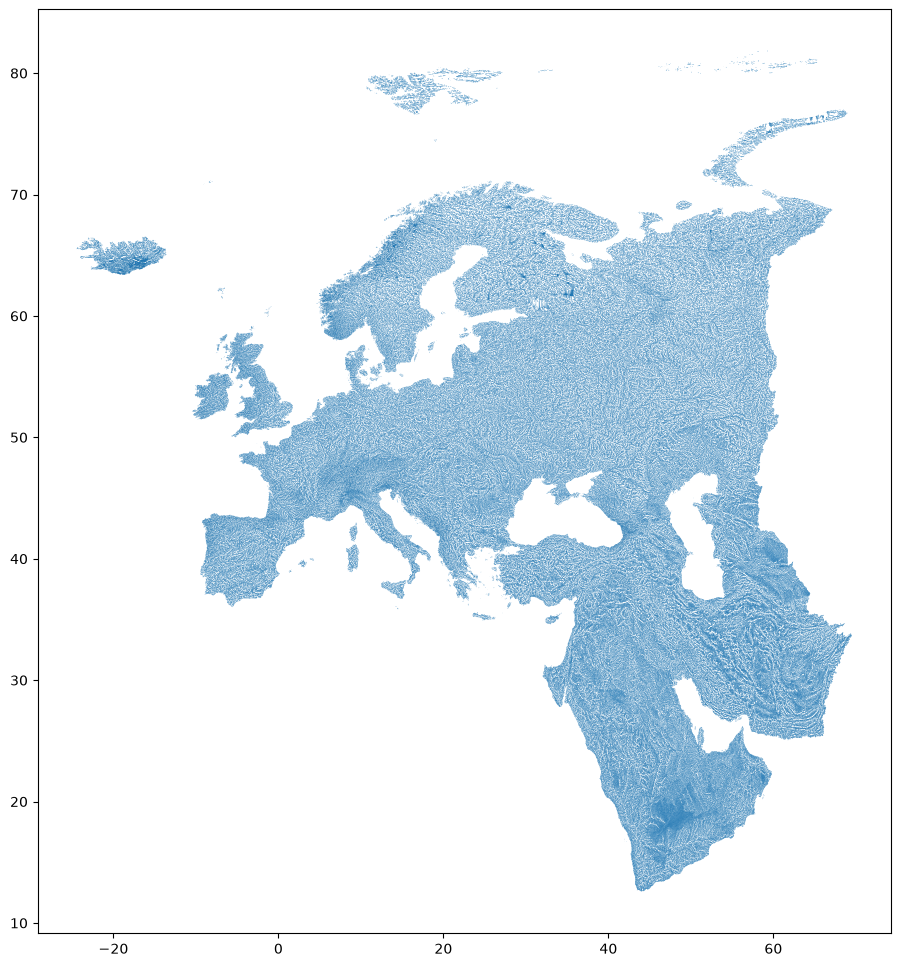

In [ ]:
import matplotlib.pyplot as plt

rivers = gpd.read_file(folder_name)

fig, ax = plt.subplots(figsize=(12,12))

rivers.plot(ax=ax, linewidth=0.2)

plt.show()

### Focus sur la France

In [47]:
from shapely.geometry import box

bbox = gpd.GeoDataFrame(
    geometry=[box(-5, 41, 10, 52)],
    crs="EPSG:4326"
)

rivers_fr = gpd.clip(rivers, bbox)

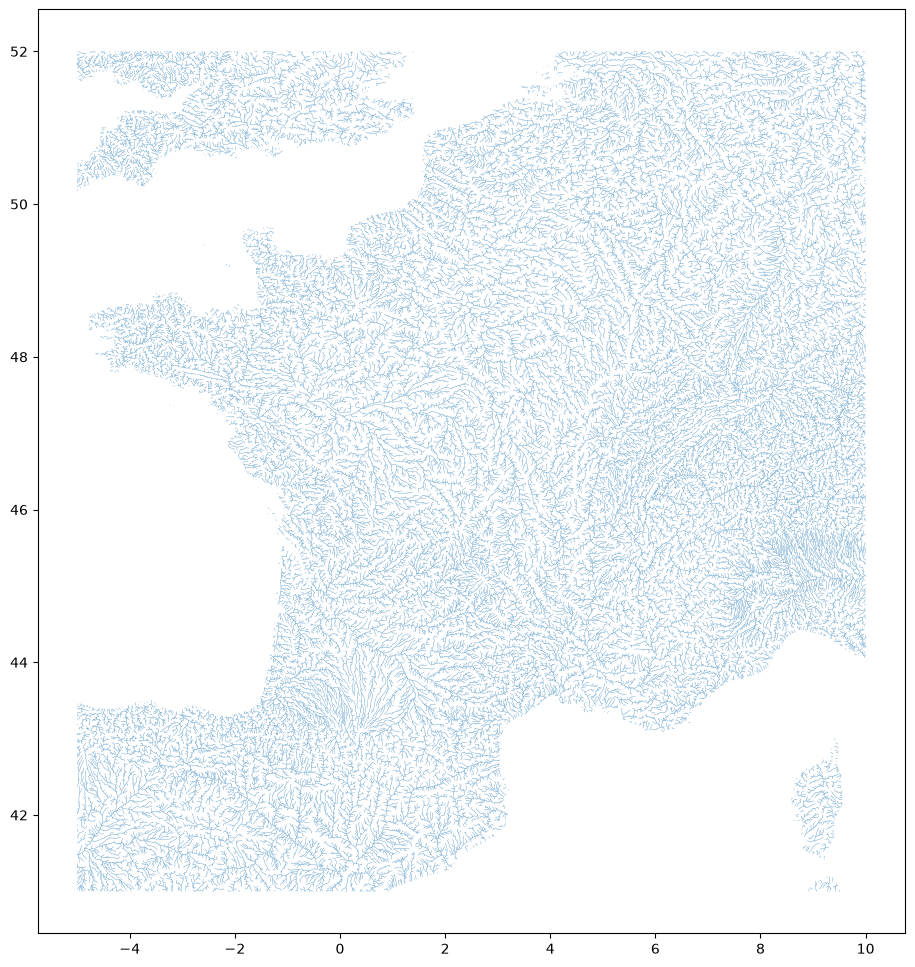

In [42]:
fig, ax = plt.subplots(figsize=(12,12))

rivers_fr.plot(ax=ax, linewidth=0.2)

plt.show()